In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    precision_recall_fscore_support, accuracy_score, balanced_accuracy_score,
    roc_auc_score, average_precision_score, matthews_corrcoef,
    confusion_matrix, precision_recall_curve
)
import matplotlib.pyplot as plt

In [2]:
merged_df = pd.read_csv('/Users/khj/Desktop/Project_ongoing/DRBP/data/DRBP_Pred_result/new_drbp_predicted_result.csv')

merged_df

,ID,sequence,DNA-binding,RNA-binding,DNA-binding probabilities,RNA-binding probabilities
0,>ENSP00000000233,MGLTVSALFSRIFGKKQMRILMVGLDAAGKTTILYKLKLGEIVTTI...,0,0,0.197959,0.000058
1,>ENSP00000000412,MFPFYSCWRTGLLLLLLAVAVRESWQTEEKTCDLVGEKGKESEKEL...,0,0,0.026668,0.000553
2,>ENSP00000000442,MSSQVVGIEPLYIKAEPASPDSPKGSSETETEPPVALAPGPAPTRC...,1,0,0.947597,0.000091
3,>ENSP00000001008,MTAEEMKATESGAQSAPLPMEGVDISPKQDEGVLKVIKREGTGTEM...,0,1,0.469457,0.000029
4,>ENSP00000001146,MLFEGLDLVSALATLAACLVSVTLLLAVSQQLWQLRWAATRDKSCK...,0,0,0.078130,0.020440
...,...,...,...,...,...,...
18216,>ENSP00000498164,MAAPVVAPPGVVVSRANKRSGAGPGGSGGGGARGAEEEPPPPLQAV...,0,0,0.237524,0.010683
18217,>ENSP00000498177,MKFNPFVTSDRSKNRKRHFNAPSHIRRKIMSSPLSKELRQKYNVRS...,0,0,0.721043,0.473582
18218,>ENSP00000498186,MQLRNPELHLGCALALRFLALVSWDIPGARALDNGLARTPTMGWLH...,0,0,0.084342,0.010173
18219,>ENSP00000498190,MSPSLQEGAQLGENKPSTCSFSIERILGLDQKKDCVPLMKPHRPWA...,0,0,0.935315,0.001034


In [3]:
DBP = merged_df[['DNA-binding','DNA-binding probabilities']]
DBP.columns = ['class','probabilities']

RBP = merged_df[['RNA-binding','RNA-binding probabilities']]
RBP.columns = ['class','probabilities']

In [7]:
def _safe_div(n, d):
    return float(n) / d if d != 0 else 0.0

def _safe_auc(y_true, y_score, kind="roc"):
    # 이진 클래스가 둘 다 존재하고 점수가 있어야 계산 가능
    if y_score is None or len(np.unique(y_true)) < 2:
        return None
    try:
        if kind == "roc":
            return float(roc_auc_score(y_true, y_score))
        elif kind == "pr":
            return float(average_precision_score(y_true, y_score))
    except Exception:
        return None


def _best_mcc_threshold(y_true, y_score, num_thresholds=11):
    """
    MCC 기준으로 최적 threshold를 찾음.
    - y_true: 정답 (0/1)
    - y_score: 예측 확률 (0~1)
    - num_thresholds: 평가할 threshold 개수 (기본 100)
    """
    if y_score is None or len(np.unique(y_true)) < 2:
        return 0.5

    thresholds = np.linspace(0, 1, num_thresholds)
    best_mcc, best_thresh = -1.0, 0.5

    for t in thresholds:
        y_pred = (y_score >= t).astype(int)
        mcc = matthews_corrcoef(y_true, y_pred)
        if mcc > best_mcc:
            best_mcc, best_thresh = mcc, t

    return float(best_thresh)
    
def _calc_all(y_true, y_pred):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred) if len(np.unique(y_true)) > 1 else 0.0
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    specificity = _safe_div(tn, tn + fp)  # TNR
    return {
        "accuracy": float(acc),
        "balanced_accuracy": float(bal_acc),
        "precision": float(precision),
        "recall": float(recall),           # = sensitivity
        "specificity": float(specificity), # TNR
        "f1": float(f1),
        "mcc": float(mcc),
        "tp": int(tp), "fp": int(fp), "tn": int(tn), "fn": int(fn),
    }

def evaluate_df(df: pd.DataFrame, pos_label=1):
    """
    df: columns = ['ID','sequence','class','predictions','probabilities']
    - class: 정답(0/1)
    - predictions: 모델 이진 예측(0/1) (있으면 기본 임계값 지표는 이것으로, 없으면 prob>=0.5 사용)
    - probabilities: 양성 클래스 확률(0~1)
    """
    # --- 입력 정리 ---
    y_true = df["class"].astype(int).to_numpy()
    y_pred_col = df["predictions"].to_numpy() if "predictions" in df.columns else None
    y_score = df["probabilities"].to_numpy() if "probabilities" in df.columns else None

    # 확률이 있으면 기본 임계값 0.5 기준 예측도 생성
    if y_pred_col is None:
        if y_score is not None:
            y_pred_default = (y_score >= 0.5).astype(int)
        else:
            raise ValueError("predictions 또는 probabilities 중 하나는 필요합니다.")
    else:
        # 혹시 float로 들어오면 0/1로 정규화
        y_pred_default = (y_pred_col >= 0.5).astype(int) if y_pred_col.dtype != int else y_pred_col.astype(int)

    # --- 임계값 0.5 지표 ---
    metrics_default = _calc_all(y_true, y_pred_default)

    # --- F1 최적 임계값 지표 (확률 있을 때만) ---
    best_thresh = _best_mcc_threshold(y_true, y_score)
    y_pred_best = (y_score >= best_thresh).astype(int) if y_score is not None else y_pred_default
    metrics_best = _calc_all(y_true, y_pred_best)

    # --- AUC류 (확률 있을 때만 유효) ---
    roc_auc = _safe_auc(y_true, y_score, kind="roc")
    pr_auc  = _safe_auc(y_true, y_score, kind="pr")

    # --- 분포 ---
    n = int(len(y_true))
    n_pos = int(np.sum(y_true == pos_label))
    n_neg = n - n_pos
    pos_rate = _safe_div(n_pos, n)

    out = {
        # 데이터 분포
        "n_samples": n,
        "n_pos": n_pos,
        "n_neg": n_neg,
        "pos_rate": pos_rate,

        # 확률 기반 지표
        "roc_auc": roc_auc,    # None이면 계산 불가(클래스 한쪽만 있거나 확률 X)
        "pr_auc": pr_auc,

        # 기본 임계값(0.5)
        "thresh_default": 0.5,
        "accuracy@0.5": metrics_default["accuracy"],
        "balanced_accuracy@0.5": metrics_default["balanced_accuracy"],
        "precision@0.5": metrics_default["precision"],
        "recall@0.5": metrics_default["recall"],
        "specificity@0.5": metrics_default["specificity"],
        "f1@0.5": metrics_default["f1"],
        "mcc@0.5": metrics_default["mcc"],
        "tp@0.5": metrics_default["tp"],
        "fp@0.5": metrics_default["fp"],
        "tn@0.5": metrics_default["tn"],
        "fn@0.5": metrics_default["fn"],

        # F1 최적 임계값
        "thresh_best_mcc": best_thresh,
        "accuracy@best_mcc": metrics_best["accuracy"],
        "balanced_accuracy@best_mcc": metrics_best["balanced_accuracy"],
        "precision@best_mcc": metrics_best["precision"],
        "recall@best_mcc": metrics_best["recall"],
        "specificity@best_mcc": metrics_best["specificity"],
        "f1@best_mcc": metrics_best["f1"],
        "mcc@best_mcc": metrics_best["mcc"],
        "tp@best_mcc": metrics_best["tp"],
        "fp@best_mcc": metrics_best["fp"],
        "tn@best_mcc": metrics_best["tn"],
        "fn@best_mcc": metrics_best["fn"],
    }
    return out
    
def threshold_metrics(df: pd.DataFrame, thresholds: np.ndarray | None = None, pos_label=1):
    """
    0~1 사이 임계값별(기본 0.1 step)로 주요 지표를 계산하여 DataFrame으로 반환.
    df: columns = ['ID','sequence','class','predictions','probabilities']
    """
    if thresholds is None:
        thresholds = np.round(np.arange(0.0, 1.0001, 0.1), 3)

    y_true = df["class"].astype(int).to_numpy()
    if "probabilities" not in df.columns:
        raise ValueError("threshold sweep를 위해서는 'probabilities' 열이 필요합니다.")
    y_score = df["probabilities"].to_numpy()

    rows = []
    for t in thresholds:
        y_pred = (y_score >= t).astype(int)
        m = _calc_all(y_true, y_pred)
        rows.append({
            "threshold": float(t),
            "accuracy": m["accuracy"],
            "balanced_accuracy": m["balanced_accuracy"],
            "precision": m["precision"],
            "recall": m["recall"],           # sensitivity
            "specificity": m["specificity"], # TNR
            "f1": m["f1"],
            "mcc": m["mcc"],
            "tp": m["tp"], "fp": m["fp"], "tn": m["tn"], "fn": m["fn"],
        })
    return pd.DataFrame(rows)

def plot_threshold_metrics(metrics_df: pd.DataFrame, best_mcc: float | None = None):
    """
    threshold_metrics() 결과 DataFrame을 받아 주요 지표를 하나의 라인 플롯으로 비교.
    best_f1 값을 주면 수직선으로 표시.
    """
    x = metrics_df["threshold"].to_numpy()

    plt.figure(figsize=(8, 5))
    for col in ["accuracy", "balanced_accuracy", "precision", "recall", "specificity", "f1", "mcc"]:
        plt.plot(x, metrics_df[col].to_numpy(), marker="o", label=col)

    if best_mcc is not None:
        plt.axvline(best_mcc, linestyle="--", linewidth=1.5, label=f"best_mcc={best_mcc:.3f}")

    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.title("Metrics vs. Threshold (0.1 step)")
    plt.xticks(x)
    plt.ylim(0.0, 1.05)
    plt.grid(True, linewidth=0.5, alpha=0.6)
    #plt.legend(loc="best", ncols=2)
    plt.savefig(
        f"/Users/khj/Desktop/Project_ongoing/DRBP/Supplementary_graph/Threshold.png",  # 파일 이름
        dpi=600,                           # 해상도 (논문용: 300~600)
        bbox_inches='tight',               # 여백 제거
        transparent=True                   # 배경 투명하게 (논문용 추천)
    )
    plt.tight_layout()
    plt.show()

In [8]:
DBP_result = evaluate_df(DBP)
for k, v in DBP_result.items():
    print(f"{k}: {v}")

n_samples: 18221
n_pos: 1447
n_neg: 16774
pos_rate: 0.0794138631249657
roc_auc: 0.8399065786892194
pr_auc: 0.3425494789849072
thresh_default: 0.5
accuracy@0.5: 0.8310191537237254
balanced_accuracy@0.5: 0.7752968464292445
precision@0.5: 0.9160423155561185
recall@0.5: 0.8310191537237254
specificity@0.5: 0.8415404793132228
f1@0.5: 0.8618186886423451
mcc@0.5: 0.37066929420373584
tp@0.5: 1026
fp@0.5: 2658
tn@0.5: 14116
fn@0.5: 421
thresh_best_mcc: 0.7000000000000001
accuracy@best_mcc: 0.8804127106086383
balanced_accuracy@best_mcc: 0.7433974684716672
precision@best_mcc: 0.9128960184709981
recall@best_mcc: 0.8804127106086383
specificity@best_mcc: 0.9062835340407774
f1@best_mcc: 0.8935941067124716
mcc@best_mcc: 0.3883808304344251
tp@best_mcc: 840
fp@best_mcc: 1572
tn@best_mcc: 15202
fn@best_mcc: 607


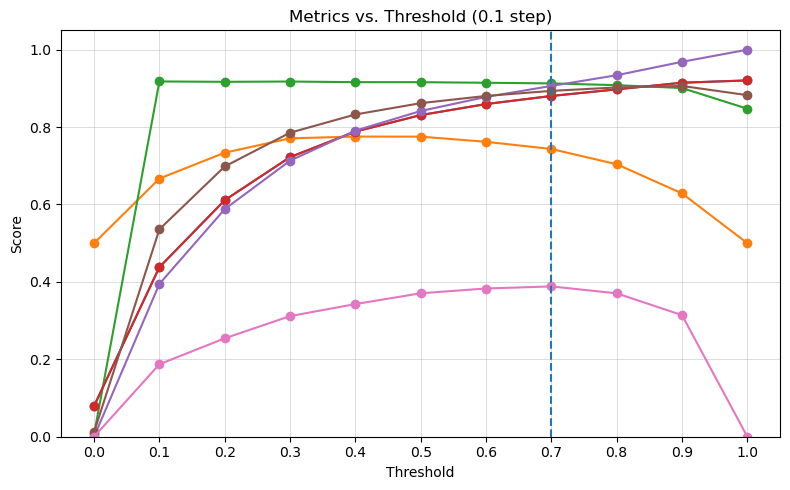

,threshold,accuracy,balanced_accuracy,precision,recall,specificity,f1,mcc,tp,fp,tn,fn
0,0.0,0.079414,0.500000,0.006307,0.079414,0.000000,0.011685,0.000000,1447,16774,0,0
1,0.1,0.438066,0.667011,0.917891,0.438066,0.394837,0.535887,0.187239,1359,10151,6623,88
2,0.2,0.611108,0.733842,0.916977,0.611108,0.587934,0.698262,0.254224,1273,6912,9862,174
3,0.3,0.722408,0.770929,0.917737,0.722408,0.713247,0.785487,0.311633,1199,4810,11964,248
4,0.4,0.788376,0.775500,0.916072,0.788376,0.790807,0.832612,0.342721,1100,3509,13265,347
5,0.5,0.831019,0.775297,0.916042,0.831019,0.841540,0.861819,0.370669,1026,2658,14116,421
6,0.6,0.859503,0.762035,0.914546,0.859503,0.877906,0.880489,0.382959,935,2048,14726,512
7,0.7,0.880413,0.743397,0.912896,0.880413,0.906284,0.893594,0.388381,840,1572,15202,607
8,0.8,0.897481,0.704045,0.908325,0.897481,0.934005,0.902421,0.370446,686,1107,15667,761
9,0.9,0.914659,0.628758,0.900921,0.914659,0.968642,0.906313,0.314149,418,526,16248,1029


In [9]:
# 1) 임계값 스위프 지표 표 만들기
DBP_metrics_df = threshold_metrics(DBP)

# 2) 이미 계산된 best_f1 임계값 구하기 (질문에 주신 함수 재사용)
DBP_best_thresh = _best_mcc_threshold(DBP["class"].astype(int).to_numpy(), DBP["probabilities"].to_numpy())

# 3) 플롯
plot_threshold_metrics(DBP_metrics_df, best_mcc=DBP_best_thresh)

# 4) 표도 보고 싶다면:
display(DBP_metrics_df)  # 노트북 환경에서

In [39]:
RBP_result = evaluate_df(RBP)
for k, v in RBP_result.items():
    print(f"{k}: {v}")

n_samples: 18221
n_pos: 351
n_neg: 17870
pos_rate: 0.019263487185116075
roc_auc: 0.9248355884617775
pr_auc: 0.3879823547875805
thresh_default: 0.5
accuracy@0.5: 0.9446792162888974
balanced_accuracy@0.5: 0.8405232790795185
precision@0.5: 0.9795572876200116
recall@0.5: 0.9446792162888974
specificity@0.5: 0.948852825965305
f1@0.5: 0.9589321332076362
mcc@0.5: 0.38172622523947414
tp@0.5: 257
fp@0.5: 914
tn@0.5: 16956
fn@0.5: 94
thresh_best_mcc: 0.9
accuracy@best_mcc: 0.9731079523626585
balanced_accuracy@best_mcc: 0.7684325063731892
precision@best_mcc: 0.9791897321948354
recall@best_mcc: 0.9731079523626585
specificity@best_mcc: 0.9813094571908226
f1@best_mcc: 0.9757604143131727
mcc@best_mcc: 0.43950582484584416
tp@best_mcc: 195
fp@best_mcc: 334
tn@best_mcc: 17536
fn@best_mcc: 156


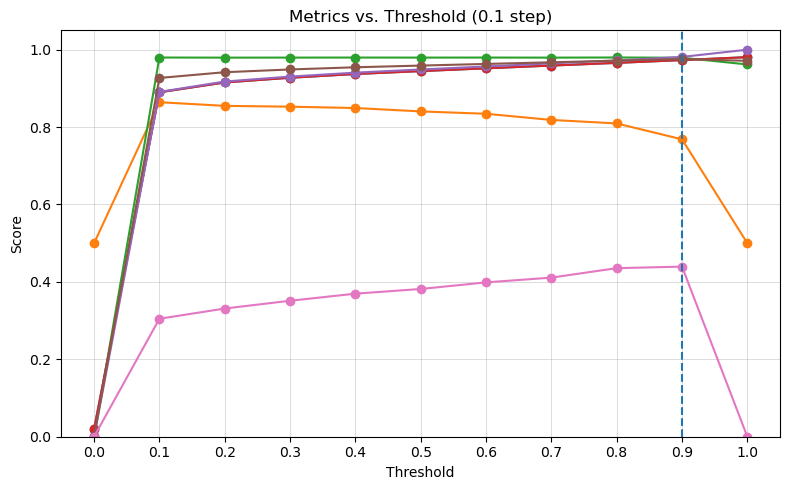

,threshold,accuracy,balanced_accuracy,precision,recall,specificity,f1,mcc,tp,fp,tn,fn
0,0.0,0.019263,0.500000,0.000371,0.019263,0.000000,0.000728,0.000000,351,17870,0,0
1,0.1,0.889907,0.864271,0.979763,0.889907,0.890935,0.926980,0.304785,294,1949,15921,57
2,0.2,0.915317,0.854881,0.979454,0.915317,0.917739,0.941776,0.331262,278,1470,16400,73
3,0.3,0.927501,0.852713,0.979560,0.927501,0.930498,0.948887,0.351282,272,1242,16628,79
4,0.4,0.937160,0.849259,0.979667,0.937160,0.940683,0.954547,0.369609,266,1060,16810,85
5,0.5,0.944679,0.840523,0.979557,0.944679,0.948853,0.958932,0.381726,257,914,16956,94
6,0.6,0.951869,0.834413,0.979670,0.951869,0.956575,0.963202,0.398799,250,776,17094,101
7,0.7,0.959003,0.818499,0.979475,0.959003,0.964633,0.967396,0.411062,236,632,17238,115
8,0.8,0.965918,0.809456,0.979826,0.965918,0.972188,0.971651,0.435505,227,497,17373,124
9,0.9,0.973108,0.768433,0.979190,0.973108,0.981309,0.975760,0.439506,195,334,17536,156


In [40]:
# 1) 임계값 스위프 지표 표 만들기
RBP_metrics_df = threshold_metrics(RBP)

# 2) 이미 계산된 best_f1 임계값 구하기 (질문에 주신 함수 재사용)
RBP_best_thresh = _best_mcc_threshold(RBP["class"].astype(int).to_numpy(), RBP["probabilities"].to_numpy())

# 3) 플롯
plot_threshold_metrics(RBP_metrics_df, best_mcc=RBP_best_thresh)

# 4) 표도 보고 싶다면:
display(RBP_metrics_df)  # 노트북 환경에서